In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from utils.data_utils import vectorize_text
from utils.model_utils import evaluate_multiclass_model, plot_confusion_matrix

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
DATA_PATH = "../../data/phishing_legit_dataset_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 5)


,text,label,phishing_type,severity,confidence
0,Thanks for your help on the analysis. I've pus...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [4]:
print("Columns:", df.columns.tolist())

if "label" not in df.columns or "text" not in df.columns:
    raise ValueError("Expected 'label' and 'text' columns in the phishing dataset.")

label_counts = df["label"].value_counts().sort_index()
print("\nLabel distribution (0 = legitimate, 1 = phishing):")
print(label_counts)

Columns: ['text', 'label', 'phishing_type', 'severity', 'confidence']

Label distribution (0 = legitimate, 1 = phishing):
label
0    4000
1    6000
Name: count, dtype: int64


In [5]:
X = df["text"].fillna("").astype(str)

phish_df = df[df["label"] == 1].copy()

X = phish_df["text"].fillna("").astype(str)
y_raw = phish_df["phishing_type"].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))

Classes: ['authority_scam', 'credential_harvesting', 'financial_scam', 'generic_phishing', 'romance_dating', 'social_engineering', 'social_engineering_advanced', 'tech_support', 'threats', 'urgency']
Number of classes: 10


In [6]:
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for i in range(len(unique_train)):
    class_idx = unique_train[i]
    count = counts_train[i]
    label_name = label_encoder.classes_[class_idx]
    print(f"{class_idx} ({label_name}): {count}")

print("\nTest label distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for i in range(len(unique_test)):
    class_idx = unique_test[i]
    count = counts_test[i]
    label_name = label_encoder.classes_[class_idx]
    print(f"{class_idx} ({label_name}): {count}")

Train size: 4800
Test size: 1200

Train label distribution:
0 (authority_scam): 400
1 (credential_harvesting): 800
2 (financial_scam): 400
3 (generic_phishing): 400
4 (romance_dating): 400
5 (social_engineering): 400
6 (social_engineering_advanced): 400
7 (tech_support): 400
8 (threats): 400
9 (urgency): 800

Test label distribution:
0 (authority_scam): 100
1 (credential_harvesting): 200
2 (financial_scam): 100
3 (generic_phishing): 100
4 (romance_dating): 100
5 (social_engineering): 100
6 (social_engineering_advanced): 100
7 (tech_support): 100
8 (threats): 100
9 (urgency): 200


In [7]:
X_train_vec, X_test_vec, vectorizer = vectorize_text(
    X_train,
    X_test,
    method="tfidf",
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2),  # unigrams + bigrams
    stop_words="english",
    verbose=True,
)

print("Training TF-IDF matrix shape:", X_train_vec.shape)
print("Test TF-IDF matrix shape:", X_test_vec.shape)


Vectorizing text using TFIDF...
Training set shape: (4800, 1228)
Test set shape: (1200, 1228)
Vocabulary size: 1228
Training TF-IDF matrix shape: (4800, 1228)
Test TF-IDF matrix shape: (1200, 1228)


In [8]:
# Convert sparse matrices to dense numpy arrays
X_train_np = X_train_vec.toarray().astype(np.float32)
X_test_np = X_test_vec.toarray().astype(np.float32)

y_train_np = y_train.astype(np.int64)
y_test_np = y_test.astype(np.int64)

print("X_train_np shape:", X_train_np.shape)
print("y_train_np shape:", y_train_np.shape)

X_train_tensor = torch.from_numpy(X_train_np)
X_test_tensor = torch.from_numpy(X_test_np)

y_train_tensor = torch.from_numpy(y_train_np)
y_test_tensor = torch.from_numpy(y_test_np)

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)


X_train_np shape: (4800, 1228)
y_train_np shape: (4800,)


(75, 19)

In [9]:
num_classes = len(label_encoder.classes_)

class FeedForwardNetMultiClass(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.3, num_classes=8):
        super().__init__()
        self.neural_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.neural_net(x)

In [10]:
input_dim = X_train_np.shape[1]
num_classes = len(label_encoder.classes_)

model = FeedForwardNetMultiClass(
    input_dim=input_dim,
    hidden_dim=128,
    dropout_p=0.3,
    num_classes=num_classes,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [11]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def evaluate_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            preds = torch.argmax(logits, dim=1)

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / total_samples
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return avg_loss, y_true, y_pred


In [12]:
EPOCHS = 10

best_val_loss = float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, y_true_val, y_pred_val = evaluate_epoch(
        model, test_loader, criterion, device
    )

    metrics_val = evaluate_multiclass_model(
        y_true=y_true_val,
        y_pred=y_pred_val,
        dataset_name=f"Phishing NN - Epoch {epoch} (Validation/Test)",
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": metrics_val["accuracy"],
        }
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"- train_loss: {train_loss:.4f} "
        f"- val_loss: {val_loss:.4f} "
        f"- val_acc: {metrics_val['accuracy']:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()

Phishing NN - Epoch 1 (Validation/Test) Metrics (average='weighted'):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 01/10 - train_loss: 1.3924 - val_loss: 0.3068 - val_acc: 1.0000
Phishing NN - Epoch 2 (Validation/Test) Metrics (average='weighted'):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 02/10 - train_loss: 0.1077 - val_loss: 0.0295 - val_acc: 1.0000
Phishing NN - Epoch 3 (Validation/Test) Metrics (average='weighted'):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 03/10 - train_loss: 0.0234 - val_loss: 0.0116 - val_acc: 1.0000
Phishing NN - Epoch 4 (Validation/Test) Metrics (average='weighted'):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 04/10 - train_loss: 0.0117 - val_loss: 0.0059 - val_acc: 1.0000
Phishing NN - Epoch 5 (Validation/Test) Metrics (average='weighted'):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Epoch 05/1

In [13]:
if "best_state_dict" in globals():
    model.load_state_dict(best_state_dict)
    print("Loaded best model state based on validation loss.")
else:
    print("Warning: best_state_dict not found; using last epoch model.")

Loaded best model state based on validation loss.


Final test loss: 0.0008
                             precision    recall  f1-score   support

             authority_scam     1.0000    1.0000    1.0000       100
      credential_harvesting     1.0000    1.0000    1.0000       200
             financial_scam     1.0000    1.0000    1.0000       100
           generic_phishing     1.0000    1.0000    1.0000       100
             romance_dating     1.0000    1.0000    1.0000       100
         social_engineering     1.0000    1.0000    1.0000       100
social_engineering_advanced     1.0000    1.0000    1.0000       100
               tech_support     1.0000    1.0000    1.0000       100
                    threats     1.0000    1.0000    1.0000       100
                    urgency     1.0000    1.0000    1.0000       200

                   accuracy                         1.0000      1200
                  macro avg     1.0000    1.0000    1.0000      1200
               weighted avg     1.0000    1.0000    1.0000      1200



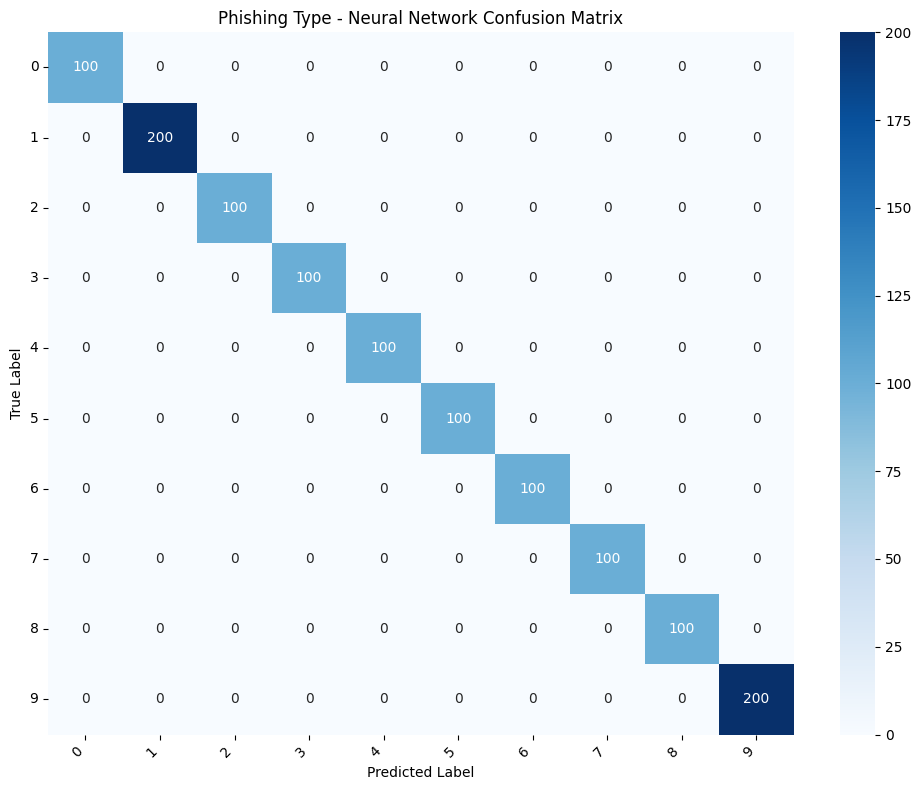

In [14]:
test_loss, y_true_test, y_pred_test = evaluate_epoch(
    model, test_loader, criterion, device
)

print(f"Final test loss: {test_loss:.4f}")

print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

plot_confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_test,
    class_names=list(range(num_classes)),  # numeric for model_utils
    title="Phishing Type - Neural Network Confusion Matrix",
    figsize=(10, 8),
)


In [15]:
def test_phishing_type_examples(examples, vectorizer, model, device, label_encoder, top_k=3):
    """
    Test the multiclass phishing-type NN on a list of example emails.

    Parameters:
    -----------
    examples : list of str
        Email text strings to classify
    vectorizer : fitted vectorizer
        TF-IDF (or similar) vectorizer used during training
    model : torch.nn.Module
        Trained multiclass phishing-type NN
    device : torch.device
        CPU or GPU device
    label_encoder : sklearn.preprocessing.LabelEncoder
        Encoder that maps class indices <-> phishing_type strings
    top_k : int
        How many top classes to display
    """
    model.eval()

    for i, text in enumerate(examples, start=1):
        X_vec = vectorizer.transform([text])
        X_np = X_vec.toarray().astype(np.float32)
        X_tensor = torch.from_numpy(X_np).to(device)

        with torch.no_grad():
            logits = model(X_tensor)                 # shape (1, num_classes)
            probs = torch.softmax(logits, dim=1)     # shape (1, num_classes)
            probs_np = probs.cpu().numpy().reshape(-1)

        # Top-1 prediction
        pred_idx = int(probs_np.argmax())
        pred_label = label_encoder.classes_[pred_idx]
        pred_conf = probs_np[pred_idx]

        # Top-k predictions
        sorted_indices = probs_np.argsort()[::-1]
        top_indices = sorted_indices[:top_k]

        print("=" * 80)
        print(f"Example {i}")
        print("-" * 80)
        print(text.strip()[:600])
        print("\nPrediction:")
        print(f"  Top-1 class:   {pred_label}")
        print(f"  Confidence:    {pred_conf:.3f}")
        print("\nTop-k predictions:")
        for j in range(len(top_indices)):
            idx = int(top_indices[j])
            class_name = label_encoder.classes_[idx]
            prob = probs_np[idx]
            print(f"  {j+1}. {class_name:25s} {prob:.3f}")
        print("=" * 80, "\n")


In [16]:
# Overall counts (on the filtered phishing-type dataset phish_df)
num_samples = len(phish_df)
num_train = len(X_train)
num_test = len(X_test)

print("=== Neural Network Phishing-Type Model Summary ===\n")
print(f"Total phishing samples (phish_df): {num_samples}")
print(f"Train size:                      {num_train}")
print(f"Test size:                       {num_test}\n")

# Class distribution in the full phishing dataset (phish_df)
print("Class distribution in full phishing dataset:")
unique_all, counts_all = np.unique(y, return_counts=True)
for i in range(len(unique_all)):
    cls_idx = unique_all[i]
    count = counts_all[i]
    label_name = label_encoder.classes_[cls_idx]
    print(f"  {cls_idx:2d} ({label_name:25s}): {count}")
print()

# Class distribution in the test set
print("Class distribution in test set:")
unique_test, counts_test = np.unique(y_true_test, return_counts=True)
for i in range(len(unique_test)):
    cls_idx = unique_test[i]
    count = counts_test[i]
    label_name = label_encoder.classes_[cls_idx]
    print(f"  {cls_idx:2d} ({label_name:25s}): {count}")
print()

# Overall accuracy + detailed classification report
test_accuracy = accuracy_score(y_true_test, y_pred_test)
print(f"Overall test accuracy: {test_accuracy:.4f}\n")

print("Detailed classification report (per class):")
print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

print("Model architecture:")
print(model)


=== Neural Network Phishing-Type Model Summary ===

Total phishing samples (phish_df): 6000
Train size:                      4800
Test size:                       1200

Class distribution in full phishing dataset:
   0 (authority_scam           ): 500
   1 (credential_harvesting    ): 1000
   2 (financial_scam           ): 500
   3 (generic_phishing         ): 500
   4 (romance_dating           ): 500
   5 (social_engineering       ): 500
   6 (social_engineering_advanced): 500
   7 (tech_support             ): 500
   8 (threats                  ): 500
   9 (urgency                  ): 1000

Class distribution in test set:
   0 (authority_scam           ): 100
   1 (credential_harvesting    ): 200
   2 (financial_scam           ): 100
   3 (generic_phishing         ): 100
   4 (romance_dating           ): 100
   5 (social_engineering       ): 100
   6 (social_engineering_advanced): 100
   7 (tech_support             ): 100
   8 (threats                  ): 100
   9 (urgency            

In [17]:
example_emails = [
    "Hi team, just a reminder that our meeting is scheduled for next Tuesday at 3 PM. Let me know if you need to reschedule.",
    "URGENT: Your bank account has been locked due to suspicious activity. Click the link below to verify your credentials and restore access immediately.",
    "We noticed a new sign-in to your email account from a Chrome browser on Windows. If this was not you, please secure your account here: http://security-check.example.com",
    "Congratulations! You've won a $500 gift card. To claim your prize, please fill out the attached form with your full name, address, and social security number.",
]

test_phishing_type_examples(
    examples=example_emails,
    vectorizer=vectorizer,
    model=model,
    device=device,
    label_encoder=label_encoder,
    top_k=3,
)


Example 1
--------------------------------------------------------------------------------
Hi team, just a reminder that our meeting is scheduled for next Tuesday at 3 PM. Let me know if you need to reschedule.

Prediction:
  Top-1 class:   romance_dating
  Confidence:    0.235

Top-k predictions:
  1. romance_dating            0.235
  2. authority_scam            0.115
  3. credential_harvesting     0.109

Example 2
--------------------------------------------------------------------------------
URGENT: Your bank account has been locked due to suspicious activity. Click the link below to verify your credentials and restore access immediately.

Prediction:
  Top-1 class:   credential_harvesting
  Confidence:    0.376

Top-k predictions:
  1. credential_harvesting     0.376
  2. social_engineering        0.350
  3. generic_phishing          0.067

Example 3
--------------------------------------------------------------------------------
We noticed a new sign-in to your email account fro

In [18]:
os.makedirs("../../models", exist_ok=True)

PHISH_TYPE_MODEL_PATH = "../../models/phishing_nn_model.pth"
torch.save(model.state_dict(), PHISH_TYPE_MODEL_PATH)
print(f"Saved phishing-type NN weights to {PHISH_TYPE_MODEL_PATH}")

PHISH_TYPE_VECTORIZER_PATH = "../../models/phishing_nn_vectorizer.joblib"
joblib.dump(vectorizer, PHISH_TYPE_VECTORIZER_PATH)
print(f"Saved phishing-type vectorizer to {PHISH_TYPE_VECTORIZER_PATH}")

PHISH_TYPE_LABEL_ENCODER_PATH = "../../models/phishing_nn_encoder.joblib"
joblib.dump(label_encoder, PHISH_TYPE_LABEL_ENCODER_PATH)
print(f"Saved phishing-type label encoder to {PHISH_TYPE_LABEL_ENCODER_PATH}")

Saved phishing-type NN weights to ../../models/phishing_nn_model.pth
Saved phishing-type vectorizer to ../../models/phishing_nn_vectorizer.joblib
Saved phishing-type label encoder to ../../models/phishing_nn_encoder.joblib
